# Extension of the Diversity Vector with Discourse Diversity (D_disc)

**$D_{\text{disc}}$: Discourse Diversity** based on the Entity-Grid model (Barzilay & Lapata, 2008): how much the entity-transition structure of a prompt's generations varies across the set.

**Data:**
Generated data from `data_generation/generations/` switchable via `DOMAIN`:
- **`storytelling_n200`**: WritingPrompts (Fan et al., 2018) test split, 200 prompts x 4 LLMs x 5 samples + >=5 human reference stories/prompt
- **`translation_ref3`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=3 human translations/paragraph
- **`translation_ref4`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=4 human translations/paragraph


In [1]:
# Load packages
import numpy as np
import pandas as pd
import json, re, os, time, warnings
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
from collections import Counter
from scipy.spatial import ConvexHull
from scipy.stats import entropy  # mannwhitneyu removed (significance testing dropped)
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
np.random.seed(42)

# Print-oriented plotting defaults: figures are sized close to their intended print width
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'legend.fontsize': 10,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10})

In [2]:
# Load spaCy
import spacy
nlp = spacy.load('en_core_web_sm', disable=['ner'])  # NER unused here (role extraction only needs the parser/tagger)
print('spaCy loaded (en_core_web_sm)')

spaCy loaded (en_core_web_sm)


In [3]:
# Configuration
DOMAIN = 'translation_ref3'  # 'storytelling_n200', 'translation_ref3' or 'translation_ref4'

SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
N_PROMPTS = 200

FIG_DIR = Path(f'../../figures/discourse_diversity/{DOMAIN}')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path(f'../../metrics/01_discourse_diversity/tables/{DOMAIN}')
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# Helper functions
def jsd(p, q):
    """Jensen-Shannon Divergence.

    Inputs must carry positive mass 
    scipy's entropy handles zero components and the 0.5*(p+q) mixture
    has no zero where p or q is positive, so no smoothing constant is needed.
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    # Normalize to probability distributions
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)

    # Compute JSD using KL divergence
    return 0.5 * (entropy(p, m) + entropy(q, m))


def finite_mask(*arrays):
    """Boolean mask (length = len(arrays[0])) that is True only where every given
    array is finite. 1D arrays are checked element-wise, 2D arrays row-wise.
    Used to drop prompt groups whose D_disc is NaN (no usable entity profile)."""

    # Convert the first array to a NumPy array to determine its length
    n = len(np.asarray(arrays[0]))
    m = np.ones(n, dtype=bool)

    # Check each array for finiteness
    for a in arrays:
        a = np.asarray(a, dtype=float)
        m &= np.isfinite(a) if a.ndim == 1 else np.isfinite(a).all(axis=1)
        
    return m

## Load Data

In [5]:
# Repo root importable regardless of the kernel's working directory
import sys

def find_repo_root(start=None):
    start = Path(start or Path.cwd())

    # Look for the repo root by checking for the presence of both 'metrics/metrics_lib/' and 'data_generation/generations/' directories
    for p in [start, *start.parents]:
        if (p / 'metrics' / 'metrics_lib').is_dir() and (p / 'data_generation' / 'generations').is_dir():
            return p

    raise FileNotFoundError("Could not locate the repo root (expected 'metrics/metrics_lib/' and "
                             "'data_generation/generations/')")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from common import data_prep
from common import MODEL_LABELS, MODEL_COLORS

# Source-keyed palette derived from the shared label-keyed one (common/constants.py)
SOURCE_COLORS = {k: MODEL_COLORS[MODEL_LABELS[k]] for k in SOURCES}

DATA_DIR = data_prep.GENERATIONS_DIR / DOMAIN
print(f"DOMAIN = {DOMAIN!r}  ({DATA_DIR})")

# Canonical load: JSONL parsing + quality filter (model: truncation / language drift; human: language drift + exact-duplicate) + storytelling human 5-cap
_df = data_prep.load_texts(DOMAIN, n_prompts=N_PROMPTS)

prompt_ids = _df.drop_duplicates('prompt_id').sort_values('prompt_id')['raw_prompt_id'].tolist()
prompt_index = {pid: i for i, pid in enumerate(prompt_ids)}

# texts[source][prompt_id] -> list of texts; prompt_id is the canonical, stable id from common/data_prep.py (0..n_prompts-1)
texts = {s: {i: [] for i in range(N_PROMPTS)} for s in SOURCES}
for _r in _df.itertuples(index=False):
    texts[_r.source][_r.prompt_id].append(_r.text)

# Generated texts: 4 LLMs x N_PROMPTS x 5 samples, minus truncated / language-drift (filtered above)
n_dropped = {key: 5 * N_PROMPTS - sum(len(texts[key][p]) for p in range(N_PROMPTS))
             for key in SOURCES if key != 'human'}

# Drop prompts where any source ends up with < 2 texts (all-diversity metrics below are pairwise and need >= 2 texts per group)
bad_prompts = sorted({p for s in SOURCES for p in range(N_PROMPTS) if len(texts[s][p]) < 2})

if bad_prompts:
    dropped_ids = [prompt_ids[p] for p in bad_prompts]
    pd.DataFrame({'prompt_id': dropped_ids}).to_csv(TABLE_DIR / 'dropped_prompts_empty_group.csv', index=False)

    # Drop the bad prompts but keep their original prompt_id as the dict key
    PROMPT_IDS = [p for p in range(N_PROMPTS) if p not in bad_prompts]
    texts = {s: {p: texts[s][p] for p in PROMPT_IDS} for s in SOURCES}

    print(f"Dropped {len(bad_prompts)}/{N_PROMPTS} prompts with < 2 texts in >= 1 source "
          f"(saved to {TABLE_DIR / 'dropped_prompts_empty_group.csv'})")
    
else:
    PROMPT_IDS = list(range(N_PROMPTS))

N_PROMPTS = len(PROMPT_IDS)


def arr(d):
    """Materialize a {prompt_id: value} dict as a numpy array, ordered by PROMPT_IDS --
    for vectorized numpy ops (np.isfinite, nanmean, boolean masking, ...)."""

    return np.array([d[p] for p in PROMPT_IDS], dtype=float)



total = sum(len(texts[s][p]) for s in SOURCES for p in texts[s])
print(f"{total:,} texts loaded across {len(SOURCES)} sources x {N_PROMPTS} prompts")
print()
print(f'{"Source":10s}  {"Prompts":>7}  {"Texts":>6}  {"Dropped":>7}  {"Min/prompt":>10}  {"Groups<2":>8}')
print("-" * 60)

# Print overview table and save to CSV
overview_rows = []
for source in SOURCES:
    sizes = [len(texts[source][p]) for p in texts[source]]
    n_undersized = sum(1 for n in sizes if n < 2)
    print(f"{source:10s}  {N_PROMPTS:>7}  {sum(sizes):>6}  {n_dropped.get(source, '-'):>7}  {min(sizes):>10}  {n_undersized:>8}")
    overview_rows.append({
        'source': source, 'prompts': N_PROMPTS, 'texts': sum(sizes),
        'dropped': n_dropped.get(source, 0), 'min_per_prompt': min(sizes),
        'groups_lt2': n_undersized,
    })
print("-" * 60)

pd.DataFrame(overview_rows).to_csv(TABLE_DIR / 'data_loading_overview.csv', index=False)

DOMAIN = 'translation_ref3'  (/Users/thwin/Desktop/Uni/Master/Masterarbeit/Masterthesis/data_generation/generations/translation_ref3)
Dropped 21/200 prompts with < 2 texts in >= 1 source (saved to ../../metrics/01_discourse_diversity/tables/translation_ref3/dropped_prompts_empty_group.csv)
4,034 texts loaded across 5 sources x 179 prompts

Source      Prompts   Texts  Dropped  Min/prompt  Groups<2
------------------------------------------------------------
human           179     600        -           3         0
llama           179     889        9           3         0
mistral         179     873       27           2         0
qwen            179     816      166           2         0
gemma           179     856       64           2         0
------------------------------------------------------------


# Simplified Entity Grid (binary)

Simple variant of the Entity-Grid model:

- Each entity is either **present (1)** or **absent (0)** per sentence
- **4 transition types**: `{(0,0), (0,1), (1,0), (1,1)}`
- Entities = noun-chunk heads (shared with the role-based variant), weighted equally
- spaCy sentence tokenizer (no minimum-length filter)

In [6]:
# Shared entity extraction + role grid + D_disc simplified (binary)
#
# No-coreference setting
# Head of every noun chunk (POS NOUN or PROPN), clustered by its normalized lemma. 
# One extraction (build_role_grid) feeds every D_disc computation below

ENTITY_HEAD_POS = {"NOUN", "PROPN"}

_SUBJ_DEPS = {"nsubj", "nsubjpass", "csubj", "csubjpass"}
_OBJ_DEPS = {"dobj", "iobj", "pobj", "attr", "oprd", "dative"}

ROLE_S, ROLE_O, ROLE_X, ROLE_ABSENT = "S", "O", "X", "-"
_ROLE_PRIORITY = {ROLE_S: 3, ROLE_O: 2, ROLE_X: 1}


# Minimum frequency threshold for entities to be included in the role grid (role-based variant)
MIN_ENTITY_FREQ = 2

SIMPLE_TRANS_TYPES = [(0, 0), (0, 1), (1, 0), (1, 1)]


def _get_role_for_token(token):
    """Grammatical role of a token, walking up the dependency chain to the
    governing subject/object."""
    node = token

    # Walk up the dependency tree until we find a subject, object or reach the root
    while True:
        if node.dep_ in _SUBJ_DEPS:
            return ROLE_S
        if node.dep_ in _OBJ_DEPS:
            return ROLE_O
        if node.head == node:
            return ROLE_X
        node = node.head


def extract_entities(sent_doc):
    """{entity_id: role} for one spaCy-parsed sentence.

    entity_id = normalized lemma of the noun-chunk head (kept only when its POS
    is NOUN/PROPN -> pronoun-headed chunks are dropped, no coreference). 
    Role priority S > O > X."""

    entity_roles = {}
    for chunk in sent_doc.noun_chunks:
        head = chunk.root

        # Only consider noun/proper noun heads (no pronouns, no coreference)
        if head.pos_ not in ENTITY_HEAD_POS:
            continue

        # Get the normalized lemma of the head token as the entity identifier
        name = head.lemma_.lower().strip()

        # Skip very short lemmas (e.g., single-character tokens)
        if len(name) < 2:
            continue

        # Determine the grammatical role of the head token and update the entity_roles dictionary
        role = _get_role_for_token(head)

        if name not in entity_roles or _ROLE_PRIORITY[role] > _ROLE_PRIORITY[entity_roles[name]]:
            entity_roles[name] = role
            
    return entity_roles


def build_role_grid(text):
    """Parse `text` once and return the role-based entity grid.

    Returns (grid, n_sents, entity_freq):
      grid: {entity_id: [role_sent1, role_sent2, ...]}, role in {S, O, X, -}
      n_sents: number of sentences in the single parse (alpha-only, no
        minimum-length threshold). Sentence spans themselves are not kept --
        they're spaCy Span objects tied to their parent Doc and can't be
        pickled on their own (see ENTITY_GRIDS caching below).
      entity_freq: {entity_id: number of sentences it appears in}
    Empty grid -> ({}, n_sents, {}) when < 2 sentences or no entities.
    """
    doc = nlp(text)
    sents = [s for s in doc.sents if any(ch.isalpha() for ch in s.text)]
    n_sents = len(sents)

    # If there are fewer than 2 sentences, return an empty grid and the sentence count
    if n_sents < 2:
        return {}, n_sents, {}

    # Entity extraction runs directly on the already-parsed sentence spans --
    # no second parse over re-joined sentence strings
    sent_entity_roles = [extract_entities(s) for s in sents]

    # Collect all unique entities across sentences
    all_entities = set()
    for roles in sent_entity_roles:
        all_entities.update(roles.keys())
    
    if not all_entities:
        return {}, n_sents, {}

    # Build the role grid and entity frequency dictionary
    grid, entity_freq = {}, {}
    for entity in all_entities:
        roles_seq, freq = [], 0

        for sent_roles in sent_entity_roles:

            if entity in sent_roles:
                roles_seq.append(sent_roles[entity])
                freq += 1

            else:
                roles_seq.append(ROLE_ABSENT)

        grid[entity] = roles_seq
        entity_freq[entity] = freq

    return grid, n_sents, entity_freq


def binary_profile_from_grid(grid, n_sents):
    """Presence/absence transition profile (4 bins) from a role grid. All
    entities weighted equally, no frequency filter. None if no usable profile."""

    # If the grid is empty or there are fewer than 2 sentences, return None
    if not grid or n_sents < 2:
        return None

    # Count transitions between presence (1) and absence (0) for each entity across sentences
    counts = Counter()
    for roles_seq in grid.values():
        pres = [0 if r == ROLE_ABSENT else 1 for r in roles_seq]

        # Count transitions between consecutive sentences
        for k in range(len(pres) - 1):
            counts[(pres[k], pres[k + 1])] += 1

    # Normalize counts to get the transition profile
    total = sum(counts.values())

    # If there are no transitions (total == 0), return None
    if total == 0:
        return None

    # Return the normalized transition profile as a NumPy array
    return np.array([counts[tt] / total for tt in SIMPLE_TRANS_TYPES])


def entity_grid_transitions(text):
    """(transitions Counter, sent_entities list[set], all_entities list) for the
    example cells, derived from the shared role grid."""

    grid, n_sents, _ = build_role_grid(text)
    all_entities = sorted(grid.keys())

    # If there are no entities, return empty structures
    if not all_entities:
        return Counter(), [], []

    # Compute the set of entities present in each sentence
    sent_entities = [
        {e for e, roles in grid.items() if roles[k] != ROLE_ABSENT}
        for k in range(n_sents)
    ]

    # Count transitions between presence (1) and absence (0) for each entity across sentences
    transitions = Counter()
    for roles_seq in grid.values():
        pres = [0 if r == ROLE_ABSENT else 1 for r in roles_seq]
        for k in range(len(pres) - 1):
            transitions[(pres[k], pres[k + 1])] += 1

    return transitions, sent_entities, all_entities


def discourse_diversity_simple_from_grids(prompt_grids):
    """D_disc (Simplified) for one prompt's cached role grids: mean pairwise JSD
    of binary profiles. Texts with no usable profile are dropped; np.nan if
    fewer than two remain."""

    # Extract binary profiles from the role grids, filtering out any that are None
    profiles = [p for p in (binary_profile_from_grid(g, s) for g, s, _ in prompt_grids) if p is not None]

    # If there are fewer than 2 valid profiles, return np.nan
    if len(profiles) < 2:
        return np.nan

    # Compute the mean pairwise Jensen-Shannon Divergence (JSD) between all valid profiles
    profiles = np.array(profiles)
    pairs = list(combinations(range(len(profiles)), 2))

    # Return the mean JSD as a float
    return float(np.mean([jsd(profiles[i], profiles[j]) for i, j in pairs]))


def discourse_diversity_simple(texts_list):
    """D_disc (Simplified) from raw texts (parses each text once). For bulk work
    use discourse_diversity_simple_from_grids on the ENTITY_GRIDS cache."""
    
    return discourse_diversity_simple_from_grids([build_role_grid(t) for t in texts_list])


print('Shared extraction (noun-chunk heads) + role grid + D_disc Simplified defined')

Shared extraction (noun-chunk heads) + role grid + D_disc Simplified defined


In [7]:
# Parse every text once with spaCy and cache the role-based entity grids to disk
# -> every downstream D_disc computation (simplified, role-based, credal sets, 
# raw statistics, MIN_ENTITY_FREQ ablation, robustness checks) reuses this cache

import hashlib, pickle

GRID_CACHE = TABLE_DIR / 'entity_grids.pkl'
GRID_EXTRACTION_VERSION = 'nounchunk-head-v2'  # v2: single spaCy parse (no NER) + dict keyed by prompt_id (no renumbering)

# Compute a fingerprint of the entity grid extraction configuration and the texts themselves
def entity_grid_fingerprint():
    h = hashlib.sha256()
    h.update(GRID_EXTRACTION_VERSION.encode())
    h.update(f'{nlp.meta["lang"]}_{nlp.meta["name"]}-{nlp.meta["version"]}/spacy{spacy.__version__}'.encode())
    h.update(f'SOURCES={SOURCES}|PROMPT_IDS={PROMPT_IDS}'.encode())

    for source in SOURCES:
        for p in PROMPT_IDS:
            for j, t in enumerate(texts[source][p]):
                h.update(f'{source}|{p}|{j}|'.encode())
                h.update(t.encode('utf-8'))
                h.update(b'\x00')

    return h.hexdigest()


FINGERPRINT = entity_grid_fingerprint()
_cached = pickle.load(open(GRID_CACHE, 'rb')) if GRID_CACHE.exists() else None

# Use the cache only if it was built from the same corpus + model + extraction logic
if isinstance(_cached, dict) and _cached.get('fingerprint') == FINGERPRINT:
    ENTITY_GRIDS = _cached['entity_grids']
    _n_texts = sum(len(ENTITY_GRIDS[s][p]) for s in SOURCES for p in PROMPT_IDS)

    print(f'Loaded cached entity grids: {GRID_CACHE}  ({_n_texts} texts)')

# Otherwise parse every text once and cache the grids to disk
else:
    if _cached is not None:
        print('Cache present but stale (corpus / N_PROMPTS / SOURCES / model changed) - re-parsing ...')

    # Parse every text once and cache the role-based entity grids to disk
    t0 = time.time()
    ENTITY_GRIDS = {}

    # Build role grids for each source and prompt, timing the operation
    for source in SOURCES:
        ENTITY_GRIDS[source] = {
            p: [build_role_grid(t) for t in texts[source][p]] for p in PROMPT_IDS
        }
        print(f'  {source:8s}: done ({time.time()-t0:.0f}s)')

    # Count the total number of texts processed across all sources and prompts
    _n_texts = sum(len(ENTITY_GRIDS[s][p]) for s in SOURCES for p in PROMPT_IDS)
    print(f'\nEntity grids parsed in {time.time()-t0:.0f}s  '
          f'({_n_texts} texts, {len(SOURCES)} sources x {N_PROMPTS} prompts)')

    # Save the entity grids and fingerprint to the cache file using pickle
    pickle.dump({'fingerprint': FINGERPRINT, 'entity_grids': ENTITY_GRIDS},
                open(GRID_CACHE, 'wb'), protocol=pickle.HIGHEST_PROTOCOL)
    
    print(f'Saved entity grids to cache: {GRID_CACHE}')

cached_grids = ENTITY_GRIDS   # alias used by the MIN_ENTITY_FREQ ablation section


  human   : done (34s)
  llama   : done (72s)
  mistral : done (112s)
  qwen    : done (145s)
  gemma   : done (183s)

Entity grids parsed in 183s  (4034 texts, 5 sources x 179 prompts)
Saved entity grids to cache: ../../metrics/01_discourse_diversity/tables/translation_ref3/entity_grids.pkl


In [8]:
# Example: both example grids (simplified + role-based) use the same entities
example_story = texts['human'][98][3].split('Little did they know')[0].strip()

ex_grid, ex_sents, ex_freq = build_role_grid(example_story)          # shared role grid; ex_sents = sentence count (int)
trans_ex, sent_ents_ex, all_ents_ex = entity_grid_transitions(example_story)
total_ex = sum(trans_ex.values()) or 1

# Shared display selection: entities passing the role-based frequency filter,
# sorted by salience (fallback: most frequent entities if none pass)
_passed = [e for e, f in sorted(ex_freq.items(), key=lambda x: -x[1]) if f >= MIN_ENTITY_FREQ]
_ranked = _passed or [e for e, _ in sorted(ex_freq.items(), key=lambda x: -x[1])]
EX_SHOW_ENTS = _ranked[:15]
EX_SHOW_SENTS = min(ex_sents, 20)

print(f'Example: Prompt 98, Story 3')
print(f'\nStory:\n{example_story}')
print(f'{ex_sents} sentences, {len(ex_freq)} entities '
      f'({len(_passed)} with freq >= {MIN_ENTITY_FREQ})')
print(f'\nShown in both example grids: {EX_SHOW_ENTS}')
print(f'\nBinary transitions:')
for tt in SIMPLE_TRANS_TYPES:
    pct = trans_ex[tt] / total_ex * 100
    bar = '\u2588' * int(pct / 2)
    print(f'  {tt[0]}\u2192{tt[1]}: {pct:5.1f}% {bar}')


IndexError: list index out of range

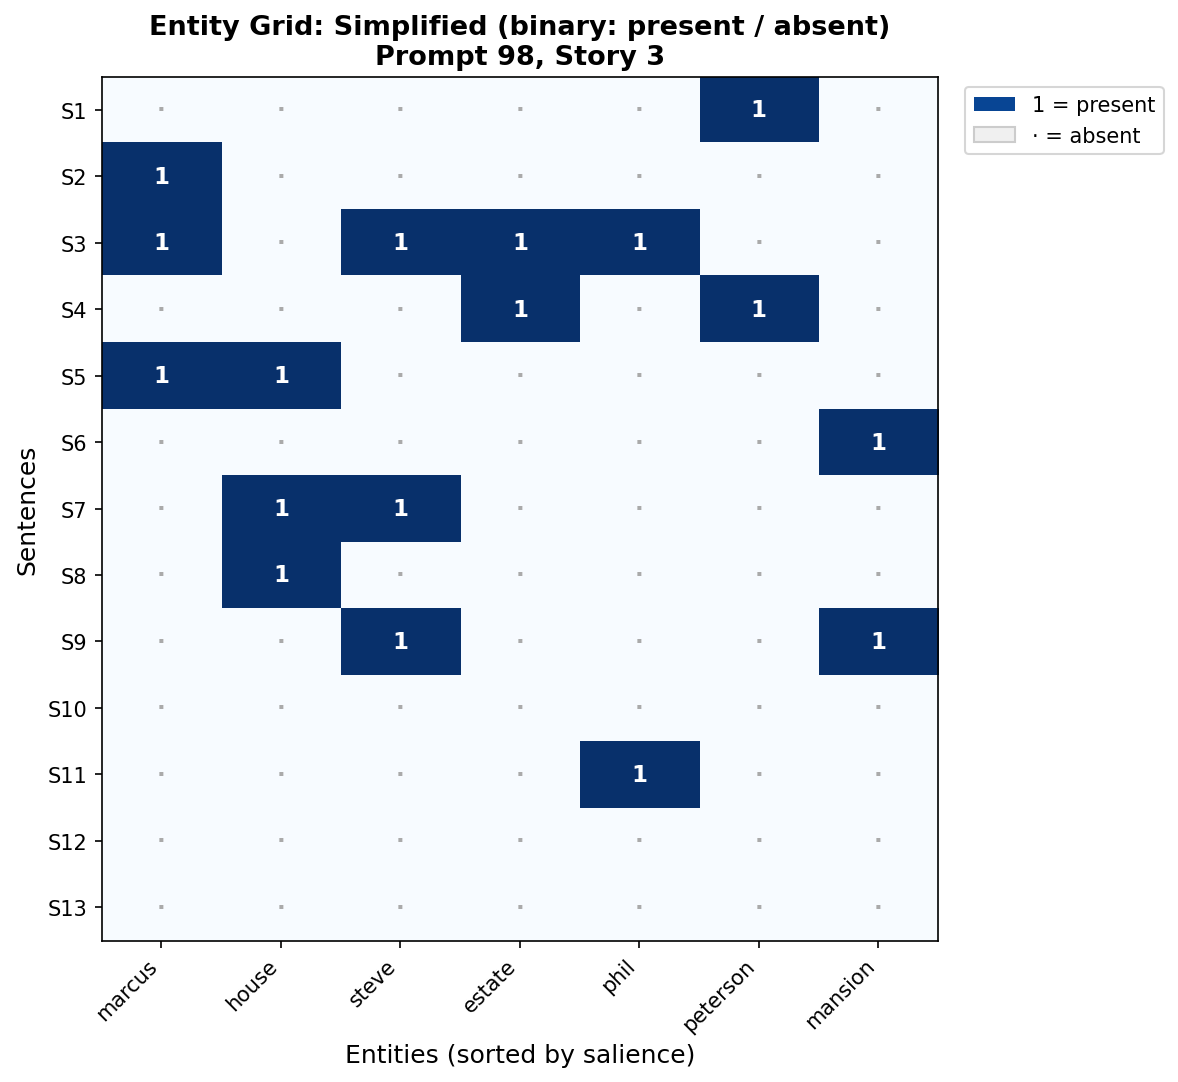

In [ ]:
# Example entity grid plot: Simplified (binary)

from matplotlib.patches import Patch as _Patch

show_ents = EX_SHOW_ENTS
show_sents = EX_SHOW_SENTS

# Binary matrix: rows = sentences, columns = entities (present / absent)
grid_bin = np.zeros((show_sents, len(show_ents)), dtype=int)
for j, ent in enumerate(show_ents):
    seq = ex_grid.get(ent, [ROLE_ABSENT] * ex_sents)
    for i in range(show_sents):
        grid_bin[i, j] = 0 if seq[i] == ROLE_ABSENT else 1

fig, ax = plt.subplots(figsize=(max(8, len(show_ents) * 0.9), show_sents * 0.45 + 1.5))
ax.imshow(grid_bin, cmap=plt.cm.Blues, aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(show_ents)))
ax.set_xticklabels(show_ents, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(show_sents))
ax.set_yticklabels([f'S{i+1}' for i in range(show_sents)], fontsize=10)
ax.set_xlabel('Entities (sorted by salience)', fontsize=12)
ax.set_ylabel('Sentences', fontsize=12)
ax.set_title('Entity Grid: Simplified (binary: present / absent)\n'
             'Prompt 98, Story 3',
             fontsize=13, fontweight='bold')

for i in range(show_sents):
    for j in range(len(show_ents)):
        present = grid_bin[i, j] == 1
        ax.text(j, i, '1' if present else '\u00b7', ha='center', va='center',
                fontsize=11, fontweight='bold', color='white' if present else '#AAAAAA')

legend_elements = [
    _Patch(facecolor='#084594', label='1 = present'),
    _Patch(facecolor='#F0F0F0', edgecolor='#CCCCCC', label='\u00b7 = absent'),
]
ax.legend(handles=legend_elements, loc='upper left',
          bbox_to_anchor=(1.02, 1), fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'entity_grid_simple_example.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
# Computation for all prompts

disc_scores_simple = {}
t0 = time.time()

# Compute D_disc (Simplified) for each source and prompt using the cached entity grids
for source in SOURCES:
    disc_scores_simple[source] = {
        p: discourse_diversity_simple_from_grids(ENTITY_GRIDS[source][p]) for p in PROMPT_IDS
    }
    print(f'  {source:8s}: done ({time.time()-t0:.0f}s)')

print('\nNA groups (D_disc undefined, < 2 usable entity profiles):')
for source in SOURCES:
    print(f'  {source:8s}: {int(np.isnan(arr(disc_scores_simple[source])).sum()):3d}/{N_PROMPTS}')

print('\nD_disc Simplified (binary)   [nan-aware mean +/- std over prompts]')
summary_rows = []
for source in SOURCES:
    d = arr(disc_scores_simple[source])
    print(f'  {source:8s}: {np.nanmean(d):.4f} +/- {np.nanstd(d):.4f}')
    summary_rows.append({'source': source, 'n_na_disc': int(np.isnan(d).sum()),
                         'Disc_mean': np.nanmean(d), 'Disc_std': np.nanstd(d)})
pd.DataFrame(summary_rows).to_csv(TABLE_DIR / 'disc_simple_summary.csv', index=False)

per_prompt_rows = [{'source': source, 'prompt_id': p, 'Disc': disc_scores_simple[source][p]}
                   for source in SOURCES for p in PROMPT_IDS]
pd.DataFrame(per_prompt_rows).to_csv(TABLE_DIR / 'disc_simple_per_prompt.csv', index=False)


  human   : done (0s)
  llama   : done (1s)
  mistral : done (1s)
  qwen    : done (2s)
  gemma   : done (2s)

NA groups (D_disc undefined, < 2 usable entity profiles):
  human   :   0/179
  llama   :   0/179
  mistral :   0/179
  qwen    :   0/179
  gemma   :   0/179

D_disc Simplified (binary)   [nan-aware mean +/- std over prompts]
  human   : 0.0015 +/- 0.0018
  llama   : 0.0006 +/- 0.0009
  mistral : 0.0008 +/- 0.0025
  qwen    : 0.0005 +/- 0.0006
  gemma   : 0.0004 +/- 0.0006


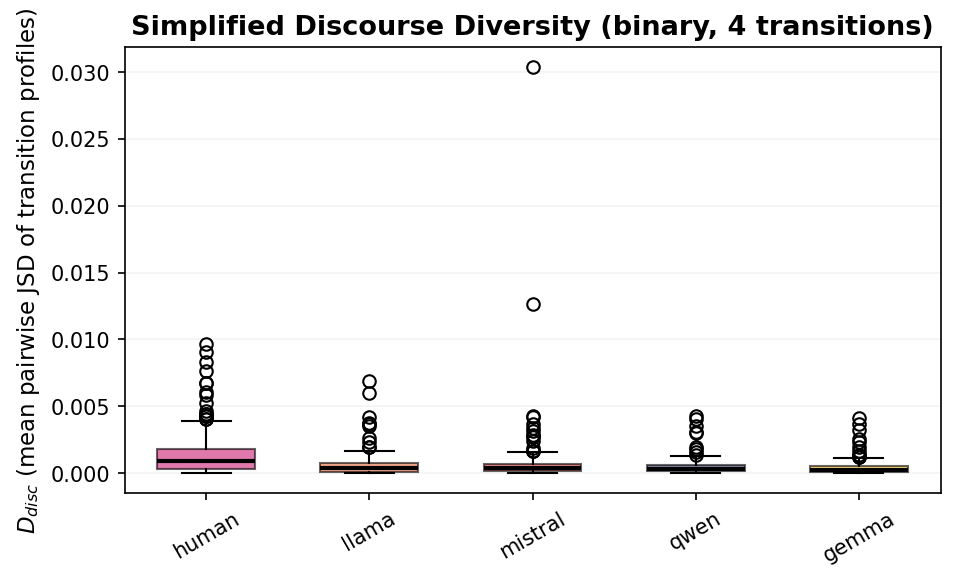

In [10]:
# Boxplot: D_disc by source

fig, ax = plt.subplots(figsize=(6.5, 4))
data = [arr(disc_scores_simple[s])[np.isfinite(arr(disc_scores_simple[s]))] for s in SOURCES]
bp = ax.boxplot(data, labels=SOURCES, patch_artist=True,
                medianprops=dict(color='black', linewidth=2), widths=0.6)
for patch, source in zip(bp['boxes'], SOURCES):
    patch.set_facecolor(SOURCE_COLORS[source])
    patch.set_alpha(0.6)
ax.set_ylabel('$D_{disc}$ (mean pairwise JSD of transition profiles)', fontsize=11)
ax.set_title('Simplified Discourse Diversity (binary, 4 transitions)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'boxplots_disc_div_simple.png', dpi=300, bbox_inches='tight')
plt.show()


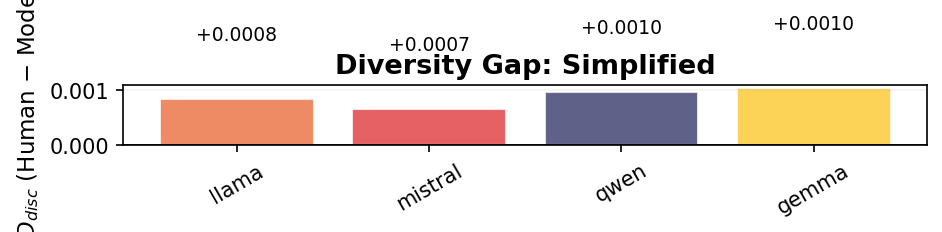

In [11]:
# Diversity Gap: D_disc (Human - Model)

human_mean = np.nanmean(arr(disc_scores_simple['human']))
llm_sources = SOURCES[1:]
deltas = [human_mean - np.nanmean(arr(disc_scores_simple[s])) for s in llm_sources]

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(llm_sources, deltas, color=[SOURCE_COLORS[s] for s in llm_sources],
              alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('$\\Delta D_{disc}$ (Human $-$ Model)', fontsize=11)
ax.set_title('Diversity Gap: Simplified', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')
for bar, delta in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width() / 2, delta + (0.001 if delta >= 0 else -0.003),
            f'{delta:+.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'diversity_gap_disc_simple.png', dpi=300, bbox_inches='tight')
plt.show()

pd.DataFrame({'model': llm_sources, 'delta_D_disc': deltas}).to_csv(
    TABLE_DIR / 'diversity_gap_disc_simple.csv', index=False)


# Role-Based Entity Grid

Extension of the simplified model with grammatical roles:

| Aspect | Part I (Simplified) | Part II (Role-Based) |
|---|---|---|
| Entity-Grid roles | binary: present (1) / absent (0) | **S**(ubject), **O**(bject), **X**(other), **–**(absent) |
| Transition types | 4 ($2^2$) | **16** ($4^2$) bigram + **64** ($4^3$) trigram |
| Role assignment | — | **Dependency Parsing** (spaCy) |
| Entity weighting | all equal | **Salience**: $w_e = \log(1 + \text{freq}(e))$ |
| Entity filter | none | $\text{freq}(e) \geq 2$* |

*see later Section for detailed analysis of frequency filter

**Grammatical Roles**

| Role | Abbreviation | Dependency Labels (spaCy) |
|---|---|---|
| Subject | **S** | `nsubj`, `nsubjpass`, `csubj` |
| Object | **O** | `dobj`, `iobj`, `pobj`, `attr`, `oprd` |
| Other | **X** | all other grammatical relations |
| Absent | **–** | entity does not appear in the sentence |

$D_{\text{disc}}^{\text{role}} = (1 - \alpha) \cdot \text{JSD}_{\text{bigram}} + \alpha \cdot \text{JSD}_{\text{trigram}}, \quad \alpha = 0.3$

In [12]:
# D_disc: Role-Based Entity-Grid Model
# Adds grammatical roles S/O/X/-, salience weighting and the MIN_ENTITY_FREQ
# filter on top of the same entities the simplified model sees (build_role_grid).

ROLES = ['S', 'O', 'X', '-']
BIGRAM_TRANSITIONS = [(r1, r2) for r1 in ROLES for r2 in ROLES]
TRIGRAM_TRANSITIONS = [(r1, r2, r3) for r1 in ROLES for r2 in ROLES for r3 in ROLES]

N_BIGRAM = len(BIGRAM_TRANSITIONS) # 16
N_TRIGRAM = len(TRIGRAM_TRANSITIONS) # 64

# Salience weighting scheme for an entity seen in f sentences
#   'none' -> w_e = 1 ; 'log' -> w_e = log(1 + f) (default) ; 'freq' -> w_e = f
WEIGHT_SCHEME = 'log'

# build_role_grid (shared cell above) is the single parser
build_entity_grid_full = build_role_grid


def _entity_weight(freq, scheme=None):
    """Salience weight for an entity appearing in `freq` sentences."""
    scheme = scheme or WEIGHT_SCHEME

    if scheme == 'none':
        return 1.0
    if scheme == 'freq':
        return float(freq)
    if scheme == 'log':
        return float(np.log1p(freq))
    
    raise ValueError(f'unknown weight scheme: {scheme!r}')


def profile_from_grid(grid, entity_freq, min_freq=MIN_ENTITY_FREQ, use_trigrams=True, weight_scheme=None):
    """Weighted bigram/trigram role-transition profile from a cached role grid.

    Returns (bigram_profile_or_None, trigram_profile_or_None, n_used).
      bigram_profile is None when no entity passes `min_freq` (or the grid is empty);
      trigram_profile is None when trigrams are off / no surviving entity spans >= 3 sentences;
      n_used = number of entities passing the frequency filter.
    """
    # If the grid is empty, return None for both profiles and 0 for n_used
    if not grid:
        return None, None, 0

    # Initialize counters for bigram and trigram transitions and a counter for the number of entities used
    bigram_counts, trigram_counts = Counter(), Counter()
    n_used = 0

    # Iterate over each entity and its corresponding sequence of roles in the grid
    for entity, roles_seq in grid.items():
        if entity_freq[entity] < min_freq:
            continue
        n_used += 1
        weight = _entity_weight(entity_freq[entity], weight_scheme)

        # Count bigram transitions for the current entity's role sequence
        for k in range(len(roles_seq) - 1):
            bigram_counts[(roles_seq[k], roles_seq[k + 1])] += weight

        # Count trigram transitions for the current entity's role sequence if trigrams are enabled and the sequence has at least 3 roles
        if use_trigrams and len(roles_seq) >= 3:
            for k in range(len(roles_seq) - 2):
                trigram_counts[(roles_seq[k], roles_seq[k + 1], roles_seq[k + 2])] += weight

    # Normalize the bigram counts to create the bigram profile
    bigram_total = sum(bigram_counts.values())
    if bigram_total == 0:
        return None, None, n_used

    bigram_profile = np.array([bigram_counts[t] / bigram_total for t in BIGRAM_TRANSITIONS])
    trigram_profile = None

    # If trigrams are enabled, normalize the trigram counts to create the trigram profile
    if use_trigrams:
        trigram_total = sum(trigram_counts.values())
        if trigram_total > 0:
            trigram_profile = np.array([trigram_counts[t] / trigram_total for t in TRIGRAM_TRANSITIONS])

    
    return bigram_profile, trigram_profile, n_used


def compute_transition_profile_full(text, use_trigrams=True, weight_scheme=None):
    """Role-based transition profile from raw text (parses once).

    Returns (bigram_profile, trigram_profile, grid, sents, entity_freq); the
    profiles follow profile_from_grid's None semantics."""

    # Build the role grid from the text and extract the bigram and trigram profiles
    grid, sents, entity_freq = build_role_grid(text)
    bi, tri, _ = profile_from_grid(grid, entity_freq, MIN_ENTITY_FREQ, use_trigrams=use_trigrams, weight_scheme=weight_scheme)

    return bi, tri, grid, sents, entity_freq


def discourse_diversity_from_grids(prompt_grids, min_freq=MIN_ENTITY_FREQ, use_trigrams=True,
                                   alpha_trigram=0.3, weight_scheme=None):
    """Role-based D_disc for one prompt's cached role grids: (1 - alpha)*JSD_bigram + alpha*JSD_trigram.

    Texts with no usable profile are dropped. The bigram term averages over all
    remaining texts, the trigram term over the subset with a trigram profile
    (>= 3 sentences) and only when >= 2 such texts remain. 
    Return np.nan if fewer than two texts have a usable profile."""

    profiles_bi, profiles_tri = [], []

    # Iterate over each role grid, its corresponding sentences and entity frequencies
    for grid, sents, entity_freq in prompt_grids:
        bi, tri, _ = profile_from_grid(grid, entity_freq, min_freq, use_trigrams=use_trigrams, weight_scheme=weight_scheme)

        # If the bigram profile is None, skip this grid, otherwise, append the bigram profile to the list
        if bi is None:
            continue
        profiles_bi.append(bi)

        # If the trigram profile is not None, append it to the list of trigram profiles
        if tri is not None:
            profiles_tri.append(tri)

    # If there are fewer than 2 valid bigram profiles, return np.nan
    if len(profiles_bi) < 2:
        return np.nan

    # Compute the mean pairwise Jensen-Shannon Divergence (JSD) for bigram profiles
    profiles_bi = np.array(profiles_bi)
    bi_pairs = list(combinations(range(len(profiles_bi)), 2))
    jsd_bi = np.mean([jsd(profiles_bi[i], profiles_bi[j]) for i, j in bi_pairs])

    # If trigrams are enabled and there are at least 2 valid trigram profiles, compute the mean pairwise JSD for trigram profiles
    if use_trigrams and len(profiles_tri) >= 2:
        profiles_tri = np.array(profiles_tri)
        tri_pairs = list(combinations(range(len(profiles_tri)), 2))
        jsd_tri = np.mean([jsd(profiles_tri[i], profiles_tri[j]) for i, j in tri_pairs])

        # Return the weighted combination of bigram and trigram JSDs based on the alpha_trigram parameter
        return float((1 - alpha_trigram) * jsd_bi + alpha_trigram * jsd_tri)
    return float(jsd_bi)


def discourse_diversity_full(texts_list, use_trigrams=True, alpha_trigram=0.3, weight_scheme=None):
    """Role-based D_disc from raw texts (parses each once). For bulk work use
    discourse_diversity_from_grids on the ENTITY_GRIDS cache."""

    # Compute the role-based discourse diversity from the provided list of texts by building role grids for each text and passing them to the discourse_diversity_from_grids function
    return discourse_diversity_from_grids([build_role_grid(t) for t in texts_list], use_trigrams=use_trigrams, alpha_trigram=alpha_trigram, weight_scheme=weight_scheme)


print('Role-based model implemented (shared noun-chunk entities)')
print(f'  Roles: {ROLES}   |   {N_BIGRAM} bigram + {N_TRIGRAM} trigram transitions')
print(f'  Entity filter: freq >= {MIN_ENTITY_FREQ}   |   weighting: {WEIGHT_SCHEME}')


Role-based model implemented (shared noun-chunk entities)
  Roles: ['S', 'O', 'X', '-']   |   16 bigram + 64 trigram transitions
  Entity filter: freq >= 2   |   weighting: log


In [13]:
# Example: Entity Grid with S/O/X/- roles  (same entities & sentences as the simplified grid)

bi_prof, tri_prof, n_used_ex = profile_from_grid(ex_grid, ex_freq, MIN_ENTITY_FREQ, use_trigrams=True)
filtered = {e: f for e, f in ex_freq.items() if f >= MIN_ENTITY_FREQ}

print(f'Example: Prompt 98, Story 3')
print(f'{ex_sents} sentences, {len(ex_grid)} entities ({len(filtered)} after freq filter)')

if bi_prof is None:
    print('\n[no usable entity profile for this text -> D_disc would be NaN for a group of such texts]')
else:
    print(f'\nTop Entities (weighting: {WEIGHT_SCHEME}):')
    for ent, freq in sorted(filtered.items(), key=lambda x: -x[1])[:8]:
        print(f'  {ent:25s} freq={freq:2d}  w={_entity_weight(freq):.2f}')

    print(f'\nBigram transitions (top 8 / {N_BIGRAM}):')
    for trans, prob in sorted(zip(BIGRAM_TRANSITIONS, bi_prof), key=lambda x: -x[1])[:8]:
        print(f'  {trans[0]}\u2192{trans[1]}: {prob:.3f} {"\u2588" * int(prob * 80)}')

    if tri_prof is not None:
        print(f'\nTrigram transitions (top 6 / {N_TRIGRAM}):')
        for trans, prob in sorted(zip(TRIGRAM_TRANSITIONS, tri_prof), key=lambda x: -x[1])[:6]:
            print(f'  {trans[0]}\u2192{trans[1]}\u2192{trans[2]}: {prob:.3f} {"\u2588" * int(prob * 80)}')

# Heatmap (EX_SHOW_ENTS / EX_SHOW_SENTS are shared with the simplified example grid)
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
show_ents = EX_SHOW_ENTS
show_sents = EX_SHOW_SENTS
role_to_num = {ROLE_S: 3, ROLE_O: 2, ROLE_X: 1, ROLE_ABSENT: 0}
role_to_label = {ROLE_S: 'S', ROLE_O: 'O', ROLE_X: 'X', ROLE_ABSENT: '\u2013'}
grid_num = np.zeros((show_sents, len(show_ents)))
for j, ent in enumerate(show_ents):
    seq = ex_grid.get(ent, [ROLE_ABSENT] * ex_sents)
    for i in range(show_sents):
        grid_num[i, j] = role_to_num[seq[i]]
cmap = ListedColormap(['#F5F5F5', '#BBDEFB', '#42A5F5', '#1565C0'])
fig, ax = plt.subplots(figsize=(max(6.5, len(show_ents)*0.75), show_sents*0.4))
ax.imshow(grid_num, cmap=cmap, aspect='auto', vmin=0, vmax=3)
ax.set_xticks(range(len(show_ents)))
ax.set_xticklabels(show_ents, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(show_sents))
ax.set_yticklabels([f'S{i+1}' for i in range(show_sents)], fontsize=10)
ax.set_xlabel('Entities (sorted by salience)')
ax.set_ylabel('Sentences')
ax.set_title('Entity Grid: Role-Based (S/O/X/\u2013)\n Prompt 98, Story 3', fontsize=13, fontweight='bold')
for i in range(show_sents):
    for j in range(len(show_ents)):
        seq = ex_grid.get(show_ents[j], [ROLE_ABSENT] * ex_sents)
        role = seq[i]
        color = 'white' if role in (ROLE_S, ROLE_O) else '#999999'
        ax.text(j, i, role_to_label[role], ha='center', va='center',
               fontsize=11, fontweight='bold', color=color)
legend_elements = [
    Patch(facecolor='#1565C0', label='S = Subject'),
    Patch(facecolor='#42A5F5', label='O = Object'),
    Patch(facecolor='#BBDEFB', label='X = Other'),
    Patch(facecolor='#F5F5F5', edgecolor='#CCCCCC', label='\u2013 = Absent'),
]
ax.legend(handles=legend_elements, loc='upper left',
          bbox_to_anchor=(1.02, 1), fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'entity_grid_full_example.png', dpi=300, bbox_inches='tight')
plt.show()


NameError: name 'ex_grid' is not defined

In [14]:
# Combined example figure: Simplified (binary) grid vs Role-Based grid side by side

from matplotlib.colors import ListedColormap as _ListedColormap
from matplotlib.patches import Patch as _Patch

# Pick the 3 most "role-varying" entities among the frequency-filter survivors
_cands = [e for e, f in ex_freq.items() if f >= MIN_ENTITY_FREQ]

def _sort_key(ent):
    # most distinct roles, then most frequent, then name (fully deterministic)
    n_roles = len({r for r in ex_grid[ent] if r != ROLE_ABSENT})
    return (-n_roles, -ex_freq[ent], ent)

_cands.sort(key=_sort_key)
EX3_ENTS = _cands[:3]
if len(EX3_ENTS) < 3:                                # pad with most frequent entities
    extra = [e for e in sorted(ex_freq, key=lambda e: (-ex_freq[e], e)) if e not in EX3_ENTS]
    EX3_ENTS = (EX3_ENTS + extra)[:3]
EX3_ENTS = sorted(EX3_ENTS, key=lambda e: (-ex_freq[e], e))   # display order: salience

# Sentences to show: whole story by default; set SHOW_FULL_STORY = False for a compact figure
SHOW_FULL_STORY = True
if SHOW_FULL_STORY:
    EX3_SENTS = list(range(ex_sents))
else:
    _rows = [i for i in range(ex_sents) if any(ex_grid[e][i] != ROLE_ABSENT for e in EX3_ENTS)]
    EX3_SENTS = list(range(min(_rows), max(_rows) + 1))


print(f'Combined example: entities {EX3_ENTS}')
print(f'Sentences shown: {len(EX3_SENTS)}  (S{EX3_SENTS[0] + 1}..S{EX3_SENTS[-1] + 1})')

# Build the two matrices (rows = sentences, cols = the 3 entities)
_role_to_num = {ROLE_S: 3, ROLE_O: 2, ROLE_X: 1, ROLE_ABSENT: 0}
_role_to_label = {ROLE_S: 'S', ROLE_O: 'O', ROLE_X: 'X', ROLE_ABSENT: '–'}

grid_bin = np.zeros((len(EX3_SENTS), 3), dtype=int)
grid_role = np.zeros((len(EX3_SENTS), 3), dtype=int)
for j, ent in enumerate(EX3_ENTS):
    seq = ex_grid[ent]
    for r, i in enumerate(EX3_SENTS):
        grid_bin[r, j] = 0 if seq[i] == ROLE_ABSENT else 1
        grid_role[r, j] = _role_to_num[seq[i]]

_ylabels = [f'S{i + 1}' for i in EX3_SENTS]
_role_cmap = _ListedColormap(['#F5F5F5', '#BBDEFB', '#42A5F5', '#1565C0'])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(7.5, len(EX3_SENTS) * 0.45 + 1.8), sharey=True)

# Left panel: Simplified (binary present / absent)
axL.imshow(grid_bin, cmap=plt.cm.Blues, aspect='auto', vmin=0, vmax=1)
for r in range(len(EX3_SENTS)):
    for j in range(3):
        if grid_bin[r, j] == 1:                       # absent cells left blank
            axL.text(j, r, '1', ha='center', va='center',
                     fontsize=12, fontweight='bold', color='white')
axL.set_title('(a) Simplified (present / absent)', fontsize=12, fontweight='bold')
axL.legend(handles=[
    _Patch(facecolor='#084594', label='1 = present'),
    _Patch(facecolor='#F0F0F0', edgecolor='#CCCCCC', label='blank = absent')],
    loc='upper center', bbox_to_anchor=(0.5, -0.22), fontsize=9, ncol=2, frameon=False)

# Right panel: Role-Based (S / O / X / -)
axR.imshow(grid_role, cmap=_role_cmap, aspect='auto', vmin=0, vmax=3)
for r in range(len(EX3_SENTS)):
    for j in range(3):
        role = ex_grid[EX3_ENTS[j]][EX3_SENTS[r]]
        axR.text(j, r, _role_to_label[role], ha='center', va='center', fontsize=12,
                 fontweight='bold', color='white' if role in (ROLE_S, ROLE_O) else '#999999')
axR.set_title('(b) Role-Based (S / O / X / –)', fontsize=12, fontweight='bold')
axR.legend(handles=[
    _Patch(facecolor='#1565C0', label='S = Subject'),
    _Patch(facecolor='#42A5F5', label='O = Object'),
    _Patch(facecolor='#BBDEFB', label='X = Other'),
    _Patch(facecolor='#F5F5F5', edgecolor='#CCCCCC', label='– = Absent')],
    loc='upper center', bbox_to_anchor=(0.5, -0.22), fontsize=9, ncol=2, frameon=False)

for ax in (axL, axR):
    ax.set_xticks(range(3))
    ax.set_xticklabels(EX3_ENTS, rotation=45, ha='right', fontsize=10)
    ax.tick_params(axis='x', length=0)
    # cell grid lines (on minor ticks at the cell borders)
    ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(EX3_SENTS), 1), minor=True)
    ax.grid(which='minor', color='#9E9E9E', linewidth=0.8)
    ax.tick_params(which='minor', length=0)
axL.set_yticks(range(len(EX3_SENTS)))
axL.set_yticklabels(_ylabels, fontsize=10)
axL.set_ylabel('Sentences', fontsize=11)

fig.suptitle('Example of binary and role-based entity grids', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'entity_grid_example_combined.png', dpi=300, bbox_inches='tight')
plt.show()


NameError: name 'ex_freq' is not defined

In [15]:
# Computation over all prompts  (from the ENTITY_GRIDS cache -- no re-parsing)

disc_scores_full = {}
t0 = time.time()

# Compute D_disc (Role-Based) for each source and prompt using the cached entity grids
for source in SOURCES:
    disc_scores_full[source] = {
        p: discourse_diversity_from_grids(ENTITY_GRIDS[source][p], use_trigrams=True, alpha_trigram=0.3)
        for p in PROMPT_IDS
    }
    
    print(f'  {source:8s}: done ({time.time()-t0:.0f}s)')

print('\nNA groups (D_disc undefined, < 2 usable entity profiles):')

for source in SOURCES:
    print(f'  {source:8s}: {int(np.isnan(arr(disc_scores_full[source])).sum()):3d}/{N_PROMPTS}')

print('\nD_disc Role-Based Model (S/O/X/-)   [nan-aware mean +/- std over prompts]')

summary_rows = []

# Compute and display the mean and standard deviation of D_disc for each source
for source in SOURCES:
    d = arr(disc_scores_full[source])

    print(f'  {source:8s}: {np.nanmean(d):.4f} +/- {np.nanstd(d):.4f}')

    summary_rows.append({'source': source, 'n_na_disc': int(np.isnan(d).sum()), 'Disc_mean': np.nanmean(d), 'Disc_std': np.nanstd(d)})

pd.DataFrame(summary_rows).to_csv(TABLE_DIR / 'disc_full_summary.csv', index=False)

per_prompt_rows = [{'source': source, 'prompt_id': p, 'Disc': disc_scores_full[source][p]}
                   for source in SOURCES for p in PROMPT_IDS]
pd.DataFrame(per_prompt_rows).to_csv(TABLE_DIR / 'disc_full_per_prompt.csv', index=False)


  human   : done (0s)
  llama   : done (1s)
  mistral : done (2s)
  qwen    : done (2s)
  gemma   : done (3s)

NA groups (D_disc undefined, < 2 usable entity profiles):
  human   :   1/179
  llama   :   2/179
  mistral :   3/179
  qwen    :   2/179
  gemma   :   3/179

D_disc Role-Based Model (S/O/X/-)   [nan-aware mean +/- std over prompts]
  human   : 0.0273 +/- 0.0276
  llama   : 0.0181 +/- 0.0189
  mistral : 0.0185 +/- 0.0235
  qwen    : 0.0155 +/- 0.0150
  gemma   : 0.0127 +/- 0.0164


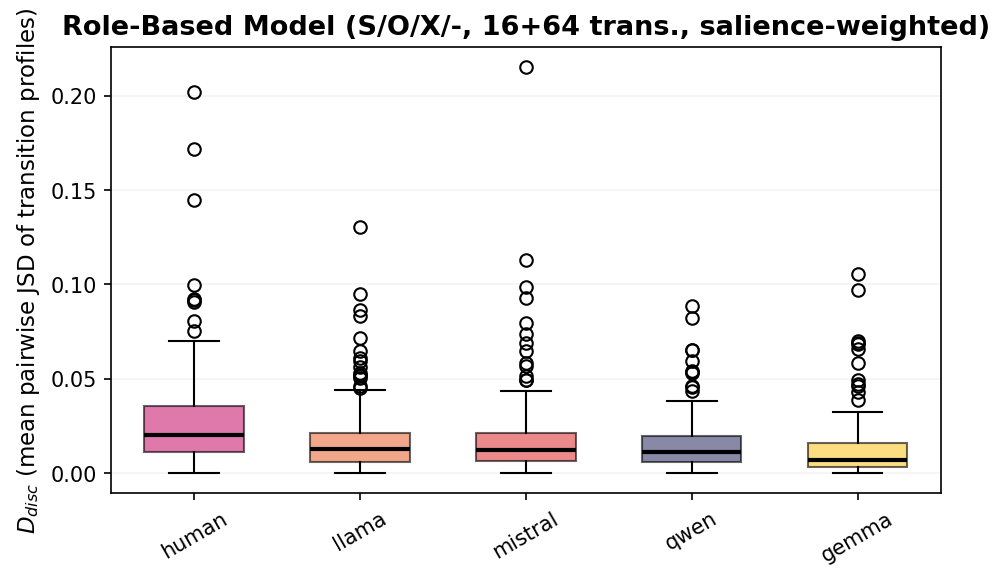

In [16]:
# Boxplot: D_disc by source

fig, ax = plt.subplots(figsize=(6.5, 4))
data = [arr(disc_scores_full[s])[np.isfinite(arr(disc_scores_full[s]))] for s in SOURCES]
bp = ax.boxplot(data, labels=SOURCES, patch_artist=True,
                medianprops=dict(color='black', linewidth=2), widths=0.6)
for patch, source in zip(bp['boxes'], SOURCES):
    patch.set_facecolor(SOURCE_COLORS[source])
    patch.set_alpha(0.6)
ax.set_ylabel('$D_{disc}$ (mean pairwise JSD of transition profiles)', fontsize=11)
ax.set_title('Role-Based Model (S/O/X/-, 16+64 trans., salience-weighted)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'diversity_scores_disc_full.png', dpi=300, bbox_inches='tight')
plt.show()


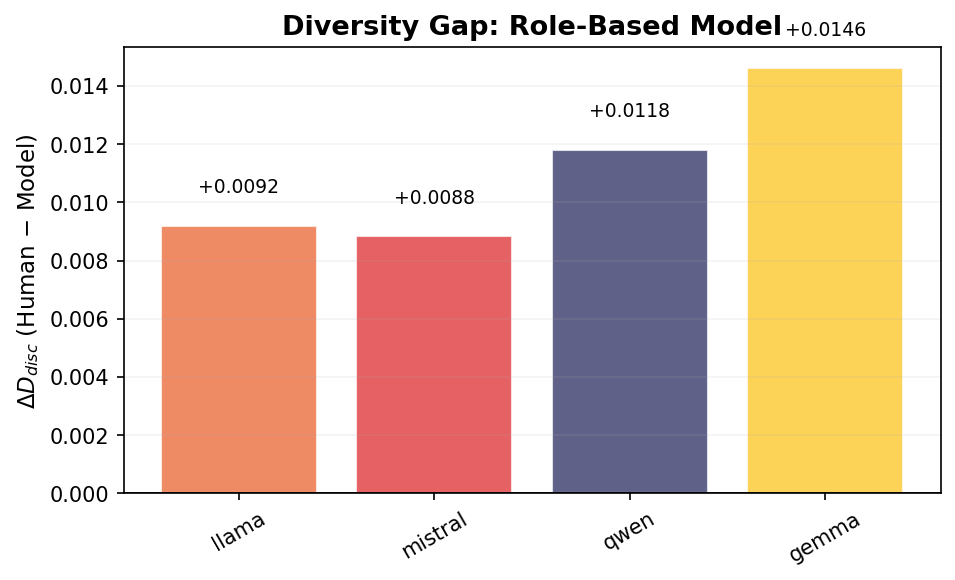

In [17]:
# Diversity Gap: D_disc (Human - Model)

human_mean = np.nanmean(arr(disc_scores_full['human']))
llm_sources = SOURCES[1:]
deltas = [human_mean - np.nanmean(arr(disc_scores_full[s])) for s in llm_sources]

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(llm_sources, deltas, color=[SOURCE_COLORS[s] for s in llm_sources],
              alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('$\\Delta D_{disc}$ (Human $-$ Model)', fontsize=11)
ax.set_title('Diversity Gap: Role-Based Model', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')
for bar, delta in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width() / 2, delta + (0.001 if delta >= 0 else -0.003),
            f'{delta:+.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'diversity_gap_disc_full.png', dpi=300, bbox_inches='tight')
plt.show()

pd.DataFrame({'model': llm_sources, 'delta_D_disc': deltas}).to_csv(
    TABLE_DIR / 'diversity_gap_disc_full.csv', index=False)


# Control Analysis: Raw Values vs. Distances

- Human-vs-Model difference in $D_{\text{disc}}$ could be an artifact of **distance computation** (mean pairwise JSD between entity-grid profiles) and not a difference in discourse structure
- JSD between distributions estimated from few counts is noisy
- Texts with fewer sentences/entities yield less stable profiles, which pushes pairwise JSD up systematically, independent of "true" structural diversity

Two checks:
1. **Raw, pooled transition profiles per source** (mean over all texts, no pairwise distance): shows whether the shape of the discourse structure actually differs between sources
2. **Confounding by text length / entity count**: tests whether $D_{\text{disc}}$ correlates with the number of sentences or usable entities

In [18]:
# Raw statistics: sentence count, entity count (total and used), transition profiles
# (from the ENTITY_GRIDS cache, no re-parsing)
import pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression


def analyze_texts_full(prompt_grids, use_trigrams=False):
    """Profiles + raw statistics for one prompt's cached role grids (role-based model).
    A text with no usable entity profile contributes a NaN-filled bigram row."""

    profiles_bi, n_sents_l, n_ent_used_l, n_ent_total_l = [], [], [], []

    # Iterate over each role grid, its corresponding sentences and entity frequencies
    for grid, n_sents, entity_freq in prompt_grids:
        bi, _, n_used = profile_from_grid(grid, entity_freq, MIN_ENTITY_FREQ, use_trigrams=use_trigrams)
        profiles_bi.append(bi if bi is not None else np.full(N_BIGRAM, np.nan))
        n_sents_l.append(n_sents)
        n_ent_total_l.append(len(entity_freq))
        n_ent_used_l.append(n_used)
    return {
        'profiles_bi': np.array(profiles_bi),
        'n_sents': np.array(n_sents_l),
        'n_entities_total': np.array(n_ent_total_l),
        'n_entities_used': np.array(n_ent_used_l),
    }


# Compute raw statistics for each source and prompt using the cached entity grids
raw_stats_full = {}
t0 = time.time()

for source in SOURCES:
    raw_stats_full[source] = {p: analyze_texts_full(ENTITY_GRIDS[source][p]) for p in PROMPT_IDS}
    print(f'  {source:8s}: done ({time.time()-t0:.0f}s)')
    
print(f'\nRaw statistics computed in {time.time()-t0:.0f}s')


  human   : done (0s)
  llama   : done (0s)
  mistral : done (0s)
  qwen    : done (0s)
  gemma   : done (0s)

Raw statistics computed in 0s


## Raw, pooled transition profiles per source

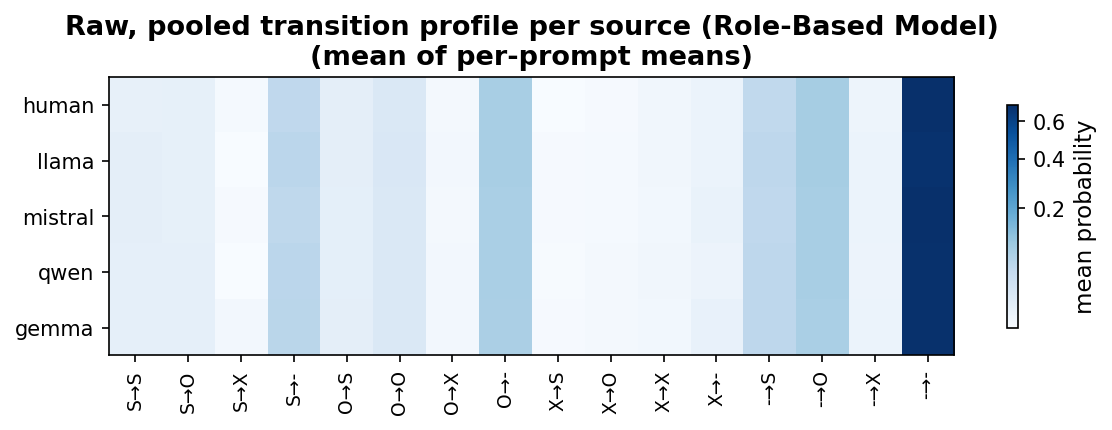

Source       H(mean profile)   D_disc (mean JSD)
------------------------------------------------
human                  1.654               0.027
llama                  1.726               0.018
mistral                1.674               0.018
qwen                   1.689               0.015
gemma                  1.701               0.013


In [19]:
# Mean transition profile per source: mean arc per prompt first (over its texts),
# then mean over prompts -> avoids prompts with more texts dominating the pooled mean
mean_profile_full = {}
for source in SOURCES:
    per_prompt_means = np.array([
        np.nanmean(raw_stats_full[source][p]['profiles_bi'], axis=0)
        for p in PROMPT_IDS
    ])
    mean_profile_full[source] = np.nanmean(per_prompt_means, axis=0)

mean_profile_df = pd.DataFrame(
    mean_profile_full,
    index=[f'{a}{b}' for a, b in BIGRAM_TRANSITIONS],
).T
mean_profile_df.index.name = "source"
mean_profile_df.to_csv(TABLE_DIR / "mean_transition_profile.csv")

# Heatmap: sources x 16 bigram transitions
from matplotlib.colors import PowerNorm

fig, ax = plt.subplots(figsize=(8, 3))
mat = np.vstack([mean_profile_full[s] for s in SOURCES])
im = ax.imshow(mat, cmap='Blues', aspect='auto', norm=PowerNorm(gamma=0.5))
ax.set_yticks(range(len(SOURCES))); ax.set_yticklabels(SOURCES)
ax.set_xticks(range(N_BIGRAM))
ax.set_xticklabels([f'{a}\u2192{b}' for a, b in BIGRAM_TRANSITIONS], rotation=90, fontsize=9)
ax.set_title('Raw, pooled transition profile per source (Role-Based Model)\n(mean of per-prompt means)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='mean probability')
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_profile_heatmap_full.png', dpi=150, bbox_inches='tight')
plt.show()

# Entropy of the pooled profile (= diversity of the "typical" structure, not a distance)
# vs. D_disc (mean pairwise JSD) -> shows whether both measures rank the sources the same way
print(f'{"Source":<10}{"H(mean profile)":>18}{"D_disc (mean JSD)":>20}')
print('-' * 48)
entropy_rows = []
for source in SOURCES:
    h = entropy(mean_profile_full[source], base=2)
    print(f'{source:<10}{h:>18.3f}{np.nanmean(arr(disc_scores_full[source])):>20.3f}')
    entropy_rows.append({'source': source, 'H_mean_profile': h,
                         'D_disc_mean_jsd': np.nanmean(arr(disc_scores_full[source]))})
pd.DataFrame(entropy_rows).to_csv(TABLE_DIR / 'entropy_vs_ddisc_full.csv', index=False)


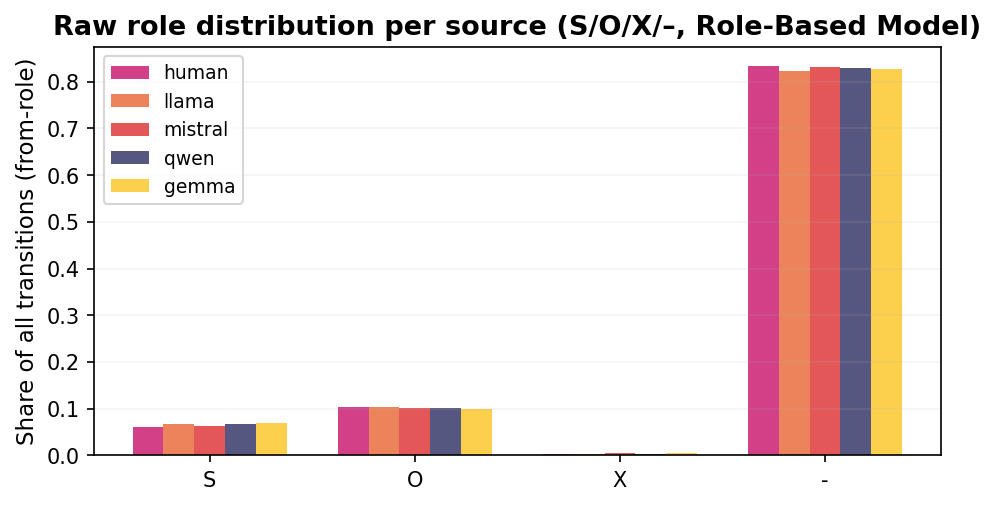

In [20]:
# Role occupancy (S/O/X/-) pooled per source (simplest "raw" summary)
role_occ_full = {}
for source in SOURCES:
    p = mean_profile_full[source].reshape(4, 4)  # rows = from-role, cols = to-role (order: ROLES)
    role_occ_full[source] = p.sum(axis=1)  # share of all transitions where an entity starts in this role

fig, ax = plt.subplots(figsize=(6.5, 3.5))
x = np.arange(4)
width = 0.15
for j, source in enumerate(SOURCES):
    ax.bar(x + j * width, role_occ_full[source], width, label=source, color=SOURCE_COLORS[source], alpha=0.85)
ax.set_xticks(x + 2 * width); ax.set_xticklabels(ROLES)
ax.set_ylabel('Share of all transitions (from-role)')
ax.set_title('Raw role distribution per source (S/O/X/\u2013, Role-Based Model)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_role_occupancy_full.png', dpi=150, bbox_inches='tight')
plt.show()

## Confounding by text length / entity count

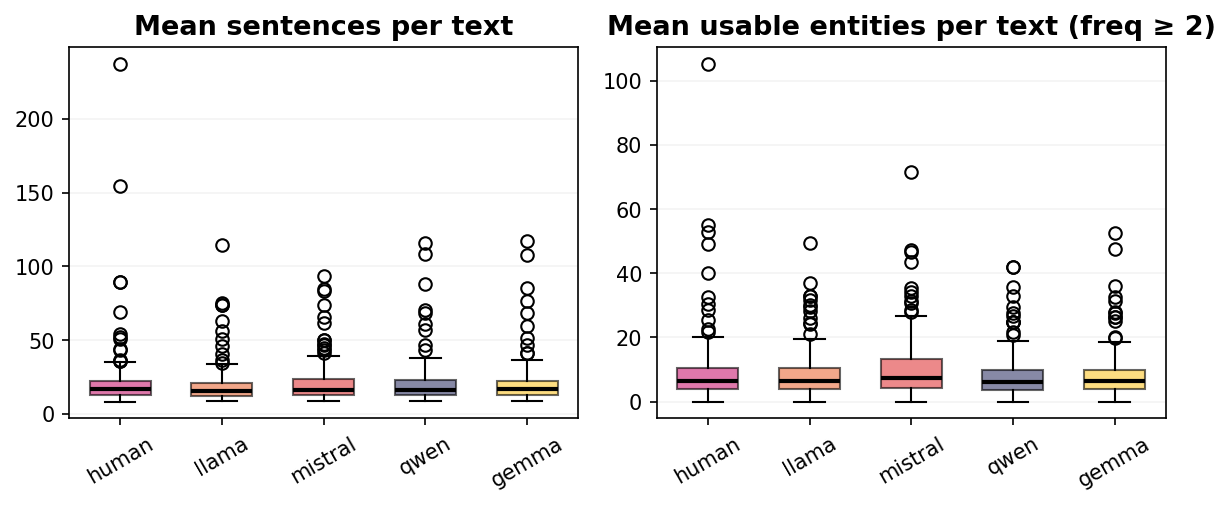

In [21]:
# Per-prompt averaged raw statistics (across the texts of a source)
mean_n_sents_full = {s: {p: raw_stats_full[s][p]['n_sents'].mean() for p in PROMPT_IDS} for s in SOURCES}
mean_n_ent_used_full = {s: {p: raw_stats_full[s][p]['n_entities_used'].mean() for p in PROMPT_IDS} for s in SOURCES}

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, data_dict, title in [
    (axes[0], mean_n_sents_full, 'Mean sentences per text'),
    (axes[1], mean_n_ent_used_full, f'Mean usable entities per text (freq \u2265 {MIN_ENTITY_FREQ})'),
]:
    data = [arr(data_dict[s]) for s in SOURCES]
    bp = ax.boxplot(data, labels=SOURCES, patch_artist=True, widths=0.6,
                     medianprops=dict(color='black', linewidth=2))
    for patch, s in zip(bp['boxes'], SOURCES):
        patch.set_facecolor(SOURCE_COLORS[s]); patch.set_alpha(0.6)
    ax.set_title(title, fontweight='bold'); ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confound_length_entities_full.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Spearman correlation D_disc and confound variables within each source (over N_PROMPTS prompts)
# -> any correlation here can only come from noise/the distance computation
# (prompt groups with D_disc = NaN are dropped pairwise)

print(f'Spearman correlation D_disc <-> confound variables (per source, over {N_PROMPTS} prompts)')
print(f'{"Source":<10}{"rho(n_sents)":>15}{"rho(n_ent_used)":>18}{"n":>6}')
print('-' * 71)
confound_rows = []
for source in SOURCES:
    d = arr(disc_scores_full[source])
    mask = np.isfinite(d)
    r1, _ = spearmanr(arr(mean_n_sents_full[source])[mask], d[mask])
    r2, _ = spearmanr(arr(mean_n_ent_used_full[source])[mask], d[mask])
    print(f'{source:<10}{r1:>15.3f}{r2:>18.3f}{int(mask.sum()):>6}')
    confound_rows.append({
        'source': source, 'rho_n_sents': r1,
        'rho_n_ent_used': r2, 'n': int(mask.sum()),
    })
pd.DataFrame(confound_rows).to_csv(TABLE_DIR / 'confound_spearman_full.csv', index=False)


Spearman correlation D_disc <-> confound variables (per source, over 179 prompts)
Source       rho(n_sents)   rho(n_ent_used)     n
-----------------------------------------------------------------------
human              -0.525            -0.498   178
llama              -0.546            -0.458   177
mistral            -0.348            -0.297   176
qwen               -0.476            -0.431   177
gemma              -0.306            -0.362   176


# Entity-Frequency Filter (MIN_ENTITY_FREQ)

- Entity-frequency filter (`MIN_ENTITY_FREQ = 2`) drops entities that appear in only one sentence before the bigram/trigram counts are built 
- Motivated by Barzilay & Lapata's "salience" concept: single mentions mostly just add `-` transitions
- Profile is already salience-weighted via `log(1 + freq)`, which softly down-weights rare entities  
-> Hard cutoff may be partly redundant with the weighting
- Plausible driver of the sparsity problem (median: 1 usable entity per text at `MIN_ENTITY_FREQ = 2`).

Checking:
1. Does usable-entity count per text increase as the filter is loosened (as expected)?
2. Does the sparsity artifact (correlation between $D_{\text{disc}}$ and entity count) shrink?
3. Does discrimination between Human and Model survive across thresholds?

In [23]:
# Entity grids were parsed once and cached above as ENTITY_GRIDS (alias: cached_grids).
# The MIN_ENTITY_FREQ ablation below reuses that cache directly
assert 'cached_grids' in dir() and cached_grids is ENTITY_GRIDS
print(f'Reusing cached entity grids: {len(SOURCES)} sources x {N_PROMPTS} prompts')


Reusing cached entity grids: 5 sources x 179 prompts


In [24]:
# Filtering for different MIN_ENTITY_FREQ threshold

def _mean_n_used(prompt_grids, min_freq):
    """Mean number of entities per text passing the frequency threshold."""
    return float(np.mean([
        sum(1 for f in entity_freq.values() if f >= min_freq)
        for _, _, entity_freq in prompt_grids
    ]))


MIN_FREQS = [1, 2, 3]
disc_scores_mf = {mf: {} for mf in MIN_FREQS}
mean_n_used_mf = {mf: {} for mf in MIN_FREQS}

for mf in MIN_FREQS:
    for source in SOURCES:
        disc_scores_mf[mf][source] = {
            p: discourse_diversity_from_grids(cached_grids[source][p], min_freq=mf,
                                              use_trigrams=True, alpha_trigram=0.3)
            for p in PROMPT_IDS
        }
        mean_n_used_mf[mf][source] = {
            p: _mean_n_used(cached_grids[source][p], mf) for p in PROMPT_IDS
        }
    n_na = sum(int(np.isnan(arr(disc_scores_mf[mf][s])).sum()) for s in SOURCES)
    print(f'MIN_ENTITY_FREQ={mf}: done  ({n_na} NA groups across all sources)')


MIN_ENTITY_FREQ=1: done  (0 NA groups across all sources)
MIN_ENTITY_FREQ=2: done  (11 NA groups across all sources)
MIN_ENTITY_FREQ=3: done  (186 NA groups across all sources)


## Does loosening the filter actually add usable entities?

In [25]:
print(f'{"MIN_ENTITY_FREQ":<18}', end='')
for s in SOURCES: print(f'{s:>10}', end='')
print()
print('-' * (18 + 10 * len(SOURCES)))

usable_entities_rows = []
for mf in MIN_FREQS:
    print(f'{mf:<18}', end='')
    row = {'min_entity_freq': mf}
    for s in SOURCES:
        val = np.median(arr(mean_n_used_mf[mf][s]))
        print(f'{val:>10.2f}', end='')
        row[s] = val
    print()
    usable_entities_rows.append(row)

print('\n(median usable entities per text, i.e. entities with freq >= MIN_ENTITY_FREQ)')

pd.DataFrame(usable_entities_rows).to_csv(TABLE_DIR / 'min_entity_freq_usable_entities.csv', index=False)

MIN_ENTITY_FREQ        human     llama   mistral      qwen     gemma
--------------------------------------------------------------------
1                      41.33     38.00     37.75     37.00     37.60
2                       6.33      6.40      7.40      6.00      6.33
3                       2.00      2.20      2.33      2.00      2.00

(median usable entities per text, i.e. entities with freq >= MIN_ENTITY_FREQ)


## Does the sparsity artifact shrink

In [26]:
print('Spearman rho(D_disc, n_entities_used) within source, by MIN_ENTITY_FREQ  (NaN groups dropped)')
min_entity_freq_spearman_rows = []
for mf in MIN_FREQS:
    print(f'MIN_ENTITY_FREQ = {mf}')
    for source in SOURCES:
        d = arr(disc_scores_mf[mf][source])
        mask = np.isfinite(d)
        r, _ = spearmanr(arr(mean_n_used_mf[mf][source])[mask], d[mask])
        print(f'  {source:<10} rho={r:+.3f}  (n={int(mask.sum())})')
        min_entity_freq_spearman_rows.append({'min_entity_freq': mf, 'source': source,
                                              'rho': r, 'n': int(mask.sum())})
    print()

pd.DataFrame(min_entity_freq_spearman_rows).to_csv(TABLE_DIR / 'min_entity_freq_spearman.csv', index=False)


Spearman rho(D_disc, n_entities_used) within source, by MIN_ENTITY_FREQ  (NaN groups dropped)
MIN_ENTITY_FREQ = 1
  human      rho=-0.366  (n=179)
  llama      rho=-0.398  (n=179)
  mistral    rho=-0.327  (n=179)
  qwen       rho=-0.414  (n=179)
  gemma      rho=-0.269  (n=179)

MIN_ENTITY_FREQ = 2
  human      rho=-0.498  (n=178)
  llama      rho=-0.458  (n=177)
  mistral    rho=-0.297  (n=176)
  qwen       rho=-0.431  (n=177)
  gemma      rho=-0.362  (n=176)

MIN_ENTITY_FREQ = 3
  human      rho=-0.429  (n=146)
  llama      rho=-0.519  (n=139)
  mistral    rho=-0.329  (n=146)
  qwen       rho=-0.440  (n=142)
  gemma      rho=-0.308  (n=136)



##  Does Human-vs-Model discrimination survive?

In [27]:
# Mean difference (Human - Models)
def mean_gap(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    return a.mean() - b.mean()


print(f'{"MIN_ENTITY_FREQ":<18}{"is_human coef":>15}{"R2":>8}{"Δ mean (H vs models)":>24}')
print('-' * 65)


ablation_rows = []
for mf in MIN_FREQS:
    rows = []
    for source in SOURCES:
        for p in PROMPT_IDS:
            rows.append({'is_human': int(source == 'human'), 'D_disc': disc_scores_mf[mf][source][p]})
    df_mf = pd.DataFrame(rows).dropna(subset=['D_disc'])
    X = df_mf[['is_human']].values
    y = df_mf['D_disc'].values
    m = LinearRegression().fit(X, y)

    h = arr(disc_scores_mf[mf]['human'])
    all_models = np.concatenate([arr(disc_scores_mf[mf][s]) for s in SOURCES if s != 'human'])
    d = mean_gap(h, all_models)

    print(f'{mf:<18}{m.coef_[0]:>+15.4f}{m.score(X, y):>8.3f}{d:>24.3f}')
    ablation_rows.append({'min_entity_freq': mf, 'is_human_coef': m.coef_[0], 'r2': m.score(X, y), 'mean_gap_h_vs_models': d})

pd.DataFrame(ablation_rows).to_csv(TABLE_DIR / 'min_entity_freq_ablation.csv', index=False)


MIN_ENTITY_FREQ     is_human coef      R2    Δ mean (H vs models)
-----------------------------------------------------------------
1                         +0.0026   0.044                   0.003
2                         +0.0111   0.043                   0.011
3                         +0.0206   0.039                   0.021


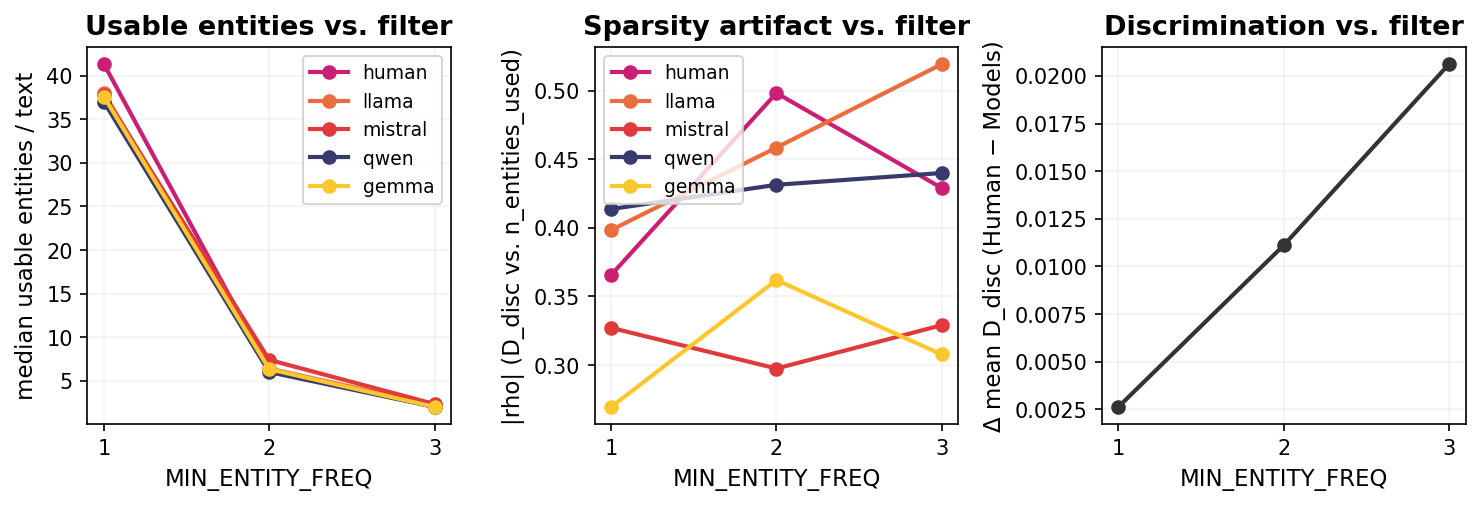

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

# Panel 1: median usable entities by threshold
ax = axes[0]
for s in SOURCES:
    ax.plot(MIN_FREQS, [np.median(arr(mean_n_used_mf[mf][s])) for mf in MIN_FREQS],
            'o-', color=SOURCE_COLORS[s], label=s, linewidth=2)
ax.set_xlabel('MIN_ENTITY_FREQ'); ax.set_ylabel('median usable entities / text')
ax.set_title('Usable entities vs. filter', fontweight='bold')
ax.set_xticks(MIN_FREQS)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)

# Panel 2: sparsity correlation magnitude by threshold
ax = axes[1]
for s in SOURCES:
    rhos = []
    for mf in MIN_FREQS:
        d = arr(disc_scores_mf[mf][s])
        mask = np.isfinite(d)
        rhos.append(abs(spearmanr(arr(mean_n_used_mf[mf][s])[mask], d[mask])[0]))
    ax.plot(MIN_FREQS, rhos, 'o-', color=SOURCE_COLORS[s], label=s, linewidth=2)
ax.set_xlabel('MIN_ENTITY_FREQ'); ax.set_ylabel('|rho| (D_disc vs. n_entities_used)')
ax.set_title('Sparsity artifact vs. filter', fontweight='bold')
ax.set_xticks(MIN_FREQS)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)

# Panel 3: discrimination (plain mean gap, not a standardized effect size) by threshold
ax = axes[2]
ds = []
for mf in MIN_FREQS:
    h = arr(disc_scores_mf[mf]['human'])
    all_models = np.concatenate([arr(disc_scores_mf[mf][s]) for s in SOURCES if s != 'human'])
    ds.append(mean_gap(h, all_models))
ax.plot(MIN_FREQS, ds, 'o-', color='#333333', linewidth=2)
ax.set_xlabel('MIN_ENTITY_FREQ'); ax.set_ylabel('Δ mean D_disc (Human − Models)')
ax.set_title('Discrimination vs. filter', fontweight='bold')
ax.set_xticks(MIN_FREQS)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ablation_min_entity_freq.png', dpi=150, bbox_inches='tight')
plt.show()


# Salience-Weighting Robustness Check

- `MIN_ENTITY_FREQ = 2` is a hard filter (drop entities seen in < 2 sentences)
- Weight `w_e` is a soft salience emphasis
- To check that D_disc does not hinge on the specific choice `w_e = log(1 + f_e)`
- Role-based model is recomputed (from the cached grids, `MIN_ENTITY_FREQ` fixed at 2, alpha = 0.3) under:

* `none` : `w_e = 1`            (plain Barzilay & Lapata, unweighted)
* `log`  : `w_e = log(1 + f_e)` (default)
* `freq` : `w_e = f_e`          (linear salience)

In [29]:
# Recompute D_disc (role-based) under the three weighting schemes, from the cached grids
WEIGHT_SCHEMES = ['none', 'log', 'freq']

disc_scores_ws = {ws: {} for ws in WEIGHT_SCHEMES}

for ws in WEIGHT_SCHEMES:
    for source in SOURCES:
        disc_scores_ws[ws][source] = {
            p: discourse_diversity_from_grids(cached_grids[source][p], min_freq=MIN_ENTITY_FREQ,
                                              use_trigrams=True, alpha_trigram=0.3, weight_scheme=ws)
            for p in PROMPT_IDS
        }
        
    print(f'weight_scheme={ws!r}: done')


# Comparison table
print(f'\n{"scheme":<8}{"source":<10}{"mean D_disc":>13}{"Δ mean (H vs M)":>18}{"rho(D,n_ent_used)":>20}')
print('-' * 69)

# Mean gap (Human vs. Models, not a standardized effect size) and Spearman
# correlation of D_disc vs. n_entities_used for each weighting
ws_rows = []
for ws in WEIGHT_SCHEMES:
    h = arr(disc_scores_ws[ws]['human']); h = h[np.isfinite(h)]
    all_models = np.concatenate([arr(disc_scores_ws[ws][s]) for s in SOURCES if s != 'human'])
    all_models = all_models[np.isfinite(all_models)]
    d_hm = mean_gap(h, all_models)

    for source in SOURCES:
        d = arr(disc_scores_ws[ws][source])
        mask = np.isfinite(d)
        rho, _ = spearmanr(arr(mean_n_used_mf[MIN_ENTITY_FREQ][source])[mask], d[mask])
        tag_d = f'{d_hm:+.3f}' if source == 'human' else ''

        print(f'{ws:<8}{source:<10}{np.nanmean(d):>13.4f}{tag_d:>18}{rho:>20.3f}')

        ws_rows.append({'weight_scheme': ws, 'source': source, 'mean_d_disc': np.nanmean(d),
                        'mean_gap_h_vs_models': d_hm if source == 'human' else None,
                        'rho_d_vs_n_ent_used': rho, 'n': int(mask.sum())})
        
pd.DataFrame(ws_rows).to_csv(TABLE_DIR / 'weight_scheme_robustness.csv', index=False)


# Per-prompt rank stability between schemes (pooled over all sources)
def _pooled(store, key):
    return np.concatenate([arr(store[key][s]) for s in SOURCES])

print('\nPer-prompt Spearman rank correlation between weighting schemes (pooled, NaN-matched):')
for a, b in [('log', 'none'), ('log', 'freq'), ('none', 'freq')]:
    va, vb = _pooled(disc_scores_ws, a), _pooled(disc_scores_ws, b)
    m = np.isfinite(va) & np.isfinite(vb)
    rho, _ = spearmanr(va[m], vb[m])
    print(f'  {a:<5} vs {b:<5}: rho = {rho:.3f}  (n={int(m.sum())})')


weight_scheme='none': done
weight_scheme='log': done
weight_scheme='freq': done

scheme  source      mean D_disc   Δ mean (H vs M)   rho(D,n_ent_used)
---------------------------------------------------------------------
none    human            0.0255            +0.010              -0.531
none    llama            0.0170                                -0.500
none    mistral          0.0176                                -0.336
none    qwen             0.0146                                -0.481
none    gemma            0.0120                                -0.409
log     human            0.0273            +0.011              -0.498
log     llama            0.0181                                -0.458
log     mistral          0.0185                                -0.297
log     qwen             0.0155                                -0.431
log     gemma            0.0127                                -0.362
freq    human            0.0298            +0.012              -0.433
freq    l

# Trigram-Weight (alpha) Robustness Check

- `D_disc = (1 - alpha) * JSD_bigram + alpha * JSD_trigram`, default `alpha = 0.3`.
- Role-based model is recomputed for `alpha in {0.0, 0.3, 0.5}`

In [30]:
# Recompute D_disc (role-based) for alpha in {0.0, 0.3, 0.5}, from the cached grids
ALPHAS = [0.0, 0.3, 0.5]

disc_scores_alpha = {a: {} for a in ALPHAS}
for a in ALPHAS:
    for source in SOURCES:
        disc_scores_alpha[a][source] = {
            p: discourse_diversity_from_grids(cached_grids[source][p], min_freq=MIN_ENTITY_FREQ,
                                              use_trigrams=True, alpha_trigram=a, weight_scheme='log')
            for p in PROMPT_IDS
        }
    print(f'alpha={a}: done')


# Comparison table 
print(f'\n{"alpha":<7}{"source":<10}{"mean D_disc":>13}{"Δ mean (H vs M)":>18}')
print('-' * 48)

# Mean gap (Human vs. Models, not a standardized effect size) for each alpha setting
alpha_rows = []
for a in ALPHAS:
    h = arr(disc_scores_alpha[a]['human']); h = h[np.isfinite(h)]
    all_models = np.concatenate([arr(disc_scores_alpha[a][s]) for s in SOURCES if s != 'human'])
    all_models = all_models[np.isfinite(all_models)]
    d_hm = mean_gap(h, all_models)

    for source in SOURCES:
        d = arr(disc_scores_alpha[a][source])
        tag_d = f'{d_hm:+.3f}' if source == 'human' else ''
        print(f'{a:<7}{source:<10}{np.nanmean(d):>13.4f}{tag_d:>18}')
        alpha_rows.append({'alpha_trigram': a, 'source': source, 'mean_d_disc': np.nanmean(d),
                           'mean_gap_h_vs_models': d_hm if source == 'human' else None})
        
pd.DataFrame(alpha_rows).to_csv(TABLE_DIR / 'alpha_trigram_robustness.csv', index=False)


# Per-prompt rank stability between alpha settings (pooled over all sources)
print('\nPer-prompt Spearman rank correlation between alpha settings (pooled, NaN-matched):')
for a, b in [(0.3, 0.0), (0.3, 0.5), (0.0, 0.5)]:
    va = np.concatenate([arr(disc_scores_alpha[a][s]) for s in SOURCES])
    vb = np.concatenate([arr(disc_scores_alpha[b][s]) for s in SOURCES])
    m = np.isfinite(va) & np.isfinite(vb)
    rho, _ = spearmanr(va[m], vb[m])
    
    print(f'  alpha={a} vs alpha={b}: rho = {rho:.3f}  (n={int(m.sum())})')


alpha=0.0: done
alpha=0.3: done
alpha=0.5: done

alpha  source      mean D_disc   Δ mean (H vs M)
------------------------------------------------
0.0    human            0.0202            +0.009
0.0    llama            0.0127                  
0.0    mistral          0.0139                  
0.0    qwen             0.0107                  
0.0    gemma            0.0088                  
0.3    human            0.0273            +0.011
0.3    llama            0.0181                  
0.3    mistral          0.0185                  
0.3    qwen             0.0155                  
0.3    gemma            0.0127                  
0.5    human            0.0321            +0.013
0.5    llama            0.0217                  
0.5    mistral          0.0215                  
0.5    qwen             0.0187                  
0.5    gemma            0.0153                  

Per-prompt Spearman rank correlation between alpha settings (pooled, NaN-matched):
  alpha=0.3 vs alpha=0.0: rho = 0.